# SOEN 471 - SmartCart Assignment Notebook

## Part 1 - Data PreProcessing

In [10]:
# Load data
import pandas as pd

user_data = pd.read_csv('data/ecommerce_user_data.csv')
product_data = pd.read_csv('data/product_details.csv')

print(user_data.head())
print(product_data.head())

  UserID ProductID  Rating   Timestamp  Category
0   U000     P0009       5  2024-09-08     Books
1   U000     P0020       1  2024-09-02      Home
2   U000     P0012       4  2024-10-18     Books
3   U000     P0013       1  2024-09-18  Clothing
4   U000     P0070       4  2024-09-16      Toys
  ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


In [11]:
# Clean the data (its already pretty clean)

# --- user_data ---

# 1. Fix data types
user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'], errors='coerce')

# 2. Standardize strings
user_data['UserID']    = user_data['UserID'].str.strip()
user_data['ProductID'] = user_data['ProductID'].str.strip()
user_data['Category']  = user_data['Category'].str.strip().str.lower()

# 3. Standardize string columns
user_data['Category'] = user_data['Category'].str.strip().str.lower()
user_data['UserID']  = user_data['UserID'].astype(str).str.strip()

# 4. Validate rating range (should be 1–5)
invalid_ratings = user_data[~user_data['Rating'].between(1, 5)]
print(f"Invalid ratings: {len(invalid_ratings)}")
user_data = user_data[user_data['Rating'].between(1, 5)]

# 5. Drop duplicates (same user rating same product twice)
before = len(user_data)
user_data = user_data.drop_duplicates(subset=['UserID', 'ProductID'])
print(f"Duplicate user-product pairs removed: {before - len(user_data)}")

# --- product_data ---

# 1. Standardize strings
product_data['ProductID']   = product_data['ProductID'].str.strip()
product_data['ProductName'] = product_data['ProductName'].str.strip()
product_data['Category']    = product_data['Category'].str.strip().str.lower()

# 2. Drop duplicate products
before = len(product_data)
product_data = product_data.drop_duplicates(subset=['ProductID'])
print(f"Duplicate products removed: {before - len(product_data)}")

# --- Summary ---
print(f"\nuser_data shape:    {user_data.shape}")
print(f"product_data shape: {product_data.shape}")
print("\nuser_data dtypes:\n",    user_data.dtypes)
print("\nproduct_data dtypes:\n", product_data.dtypes)

Invalid ratings: 0
Duplicate user-product pairs removed: 0
Duplicate products removed: 0

user_data shape:    (724, 5)
product_data shape: (100, 3)

user_data dtypes:
 UserID                  str
ProductID               str
Rating                int64
Timestamp    datetime64[us]
Category                str
dtype: object

product_data dtypes:
 ProductID      str
ProductName    str
Category       str
dtype: object


In [12]:
# Convert into user-item matrix
user_item_matrix = user_data.pivot_table(
        values='Rating',
        index='UserID',
        columns='ProductID',
        fill_value=0
    )

print(user_item_matrix.head())

ProductID  P0000  P0001  P0002  P0003  P0004  P0005  P0006  P0007  P0008  \
UserID                                                                     
U000         0.0    0.0    0.0    3.0    0.0    5.0    0.0    3.0    0.0   
U001         0.0    0.0    3.0    0.0    0.0    0.0    0.0    0.0    0.0   
U002         0.0    0.0    0.0    0.0    0.0    5.0    0.0    0.0    0.0   
U003         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U004         0.0    3.0    0.0    0.0    0.0    0.0    2.0    0.0    0.0   

ProductID  P0009  ...  P0090  P0091  P0092  P0093  P0094  P0095  P0096  P0097  \
UserID            ...                                                           
U000         5.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U001         0.0  ...    0.0    5.0    0.0    0.0    0.0    3.0    0.0    0.0   
U002         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U003         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.

In [13]:
# Group by user and category
agg_user_data = user_data.groupby(['UserID', 'Category'])['Rating'].agg(
    AverageRating='mean',
    Count='count'
)

print(agg_user_data.head(20))

                    AverageRating  Count
UserID Category                         
U000   books             3.666667      6
       clothing          1.666667      3
       electronics       3.666667      3
       home              1.000000      2
       toys              3.500000      6
U001   beauty            4.000000      1
       books             2.500000      4
       clothing          2.500000      4
       electronics       4.000000      2
       home              2.000000      1
       toys              4.000000      1
U002   beauty            3.000000      3
       books             1.000000      1
       clothing          1.000000      1
       electronics       2.000000      1
       home              2.000000      2
       toys              2.833333      6
U003   beauty            3.333333      3
       books             3.000000      1
       clothing          1.333333      3


## Part 2 - User-Based Collaborative Filtering (Cosine Similarity) 

UserID      U000      U001      U002      U003      U004      U005      U006  \
UserID                                                                         
U000    1.000000  0.063071  0.195522  0.023466  0.065412  0.161251  0.160096   
U001    0.063071  1.000000  0.190861  0.000000  0.111332  0.009540  0.000000   
U002    0.195522  0.190861  1.000000  0.065094  0.111662  0.050830  0.027756   
U003    0.023466  0.000000  0.065094  1.000000  0.035737  0.104116  0.026650   
U004    0.065412  0.111332  0.111662  0.035737  1.000000  0.159064  0.057144   

UserID      U007      U008      U009  ...      U040      U041      U042  \
UserID                                ...                                 
U000    0.092083  0.238263  0.274844  ...  0.241693  0.129483  0.156790   
U001    0.172286  0.167460  0.017593  ...  0.121540  0.024075  0.097953   
U002    0.055877  0.000000  0.181229  ...  0.144756  0.000000  0.217465   
U003    0.000000  0.025384  0.288009  ...  0.243836  0.000000  0

<Axes: xlabel='UserID', ylabel='UserID'>

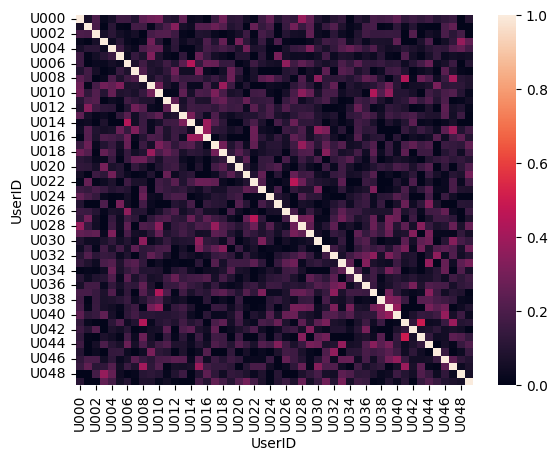

In [14]:
# Compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
from seaborn import heatmap

similarity_matrix = cosine_similarity(user_item_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=user_item_matrix.index, columns=user_item_matrix.index)
print(similarity_df.head())

heatmap(similarity_df)


In [15]:
def recommend_products(target_user, user_item_matrix, similarity_df, top_n_users=5, top_n_products=5):
    # 1. Get top n similar users (excluding the user themselves)
    similar_users = similarity_df[target_user].sort_values(ascending=False)[1:top_n_users+1].index
    
    # 2. Get products the target user hasn't rated yet (value is 0)
    target_user_ratings = user_item_matrix.loc[target_user]
    unrated_products = target_user_ratings[target_user_ratings == 0].index
    
    # 3. Calculate weighted average scores for unrated products
    product_scores = {}
    for product in unrated_products:
        weights = 0
        score = 0
        for sim_user in similar_users:
            # Check if the similar user has rated this product
            sim_rating = user_item_matrix.loc[sim_user, product]
            if sim_rating > 0:
                similarity = similarity_df.loc[target_user, sim_user]
                score += similarity * sim_rating
                weights += similarity
        
        if weights > 0:
            product_scores[product] = score / weights
        else:
            product_scores[product] = 0
            
    # 4. Sort and return the top N recommendations
    recommendations = sorted(product_scores.items(), key=lambda x: x[1], reverse=True)[:top_n_products]
    return recommendations

# Example usage for User U000
recs = recommend_products('U000', user_item_matrix, similarity_df)

if recs:
    recs_df = (
        pd.DataFrame(recs, columns=['ProductID', 'Score'])
          .merge(product_data[['ProductID', 'ProductName', 'Category']], on='ProductID', how='left')
          .sort_values('Score', ascending=False)
          .reset_index(drop=True)
    )
    print("Top recommendations for U000:")
    print(recs_df.to_string(index=False))
else:
    print("No recommendations for U000.")

Top recommendations for U000:
ProductID  Score   ProductName    Category
    P0029    5.0 Books Item 29 electronics
    P0030    5.0 Books Item 30       books
    P0032    5.0  Toys Item 32      beauty
    P0041    5.0 Books Item 41        home
    P0062    5.0 Books Item 62    clothing


In [16]:
# Implement evaluation metrics
from sklearn.metrics import precision_score

# Simplified Precision@K check
# See if the recommended products' categories match the user's top categories
def evaluate_recs(target_user, recommendations, user_data, product_data):
    user_fav_categories = user_data[user_data['UserID'] == target_user]['Category'].unique()
    
    hits = 0
    for prod_id, score in recommendations:
        category = product_data[product_data['ProductID'] == prod_id]['Category'].values[0]
        if category in user_fav_categories:
            hits += 1
            
    precision_at_k = hits / len(recommendations) if recommendations else 0
    return precision_at_k

print(f"Precision@5 for U000: {evaluate_recs('U000', recs, user_data, product_data)}")


Precision@5 for U000: 0.8


## Part 3 - Association Rule Mining (Apriori)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations, chain
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from typing import List, Dict, Tuple, Set

In [18]:
# Convert each user-product interations into a transaction
# Transaction = {UserID: set/list of ProductIDs}
transactions = user_data.groupby('UserID')['ProductID'].apply(list).tolist()
transactions = [t for t in transactions if t] # Exclude empty transactions

product_name_map = dict(zip(product_data['ProductID'], product_data['ProductName']))
def get_product_names(product_ids):
    return [product_name_map.get(pid, pid) for pid in product_ids]

print(f"\nTransaction Statistics:")
print(f"  Total transactions: {len(transactions)}")
print(f"  Average transaction size: {np.mean([len(t) for t in transactions]):.2f} items")
print(f"  Max transaction size: {max([len(t) for t in transactions])} items")
print(f"  Min transaction size: {min([len(t) for t in transactions])} items")

# Sample transactions
print("\nSample Transactions:")
for i, trans in enumerate(transactions[:5], 1):
    print(f"  Transaction {i}: {trans[:5]}{'...' if len(trans) > 5 else ''}")


Transaction Statistics:
  Total transactions: 50
  Average transaction size: 14.48 items
  Max transaction size: 20 items
  Min transaction size: 10 items

Sample Transactions:
  Transaction 1: ['P0009', 'P0020', 'P0012', 'P0013', 'P0070']...
  Transaction 2: ['P0051', 'P0055', 'P0095', 'P0033', 'P0002']...
  Transaction 3: ['P0083', 'P0081', 'P0020', 'P0005', 'P0049']...
  Transaction 4: ['P0097', 'P0053', 'P0032', 'P0023', 'P0046']...
  Transaction 5: ['P0052', 'P0092', 'P0019', 'P0077', 'P0083']...


In [19]:
# Encode transactions using TransactionEncoder
# Apriori algo in mlxtend needs one-hot encoding
# Each row -> 1 transaction & each column -> 1 product
# Value = 0 is product not in transaction & value = 1 is product in transaction

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nTransaction df shape: {df_trans.shape}")
print(f"Number of unique products: {df_trans.shape[1]}")
print(f"\nTransaction df preview:")
print(df_trans.iloc[:5, :10])


Transaction df shape: (50, 100)
Number of unique products: 100

Transaction df preview:
   P0000  P0001  P0002  P0003  P0004  P0005  P0006  P0007  P0008  P0009
0  False  False  False   True  False   True  False   True  False   True
1  False  False   True  False  False  False  False  False  False  False
2  False  False  False  False  False   True  False  False  False  False
3  False  False  False  False  False  False  False  False  False  False
4  False   True  False  False  False  False   True  False  False  False


In [ ]:
from mlxtend.frequent_patterns import fpgrowth

# This notebook cell takes a few minutes to run (approximately 5 min with Apriori, approximately 1 min 20s with fpgrowth)
# Minimum support threshold -- Can change
MIN_SUPPORT = 0.01

# Using FP-growth instead of Apriori to find the most frequent itemset
# FP-Growth is typically 10–50x faster than Apriori on large datasets because it avoids repeatedly scanning the data and uses a tree structure instead.
frequent_itemsets = fpgrowth(df_trans, min_support=MIN_SUPPORT, use_colnames=True)

# ------ IF APRIORI IS MANDATORY UNCOMMENT THIS LINE AND COMMENT THE PREVIOUS ONE ------
# frequent_itemsets = apriori(df_trans, min_support=MIN_SUPPORT, use_colnames=True)

# Display frequent itemsets
print(f"\nFound {len(frequent_itemsets)} frequent itemsets")
print(f"\nFrequent itemsets preview:")
print(frequent_itemsets.head(10))


Found 7811785 frequent itemsets

Frequent itemsets preview:
   support            itemsets
0     0.34  frozenset({P0070})
1     0.22  frozenset({P0044})
2     0.20  frozenset({P0079})
3     0.18  frozenset({P0071})
4     0.18  frozenset({P0050})
5     0.18  frozenset({P0021})
6     0.16  frozenset({P0003})
7     0.16  frozenset({P0005})
8     0.16  frozenset({P0033})
9     0.16  frozenset({P0009})


In [28]:
# Convert frozenset to readable format (list)
frequent_itemsets['itemsets_list'] = frequent_itemsets['itemsets'].apply(list)
frequent_itemsets['itemsets_str'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(x))

print("\nFrequent itemsets - Readable format:")
print(frequent_itemsets[['support', 'itemsets_str']].head())


Frequent itemsets - Readable format:
   support itemsets_str
0     0.34        P0070
1     0.22        P0044
2     0.20        P0079
3     0.18        P0071
4     0.18        P0050


In [29]:
# Frequent itemsets' size distribution
itemset_sizes = frequent_itemsets['itemsets'].apply(len)
print(f"\nItemset size distribution:")
size_dist = itemset_sizes.value_counts().sort_index()
for size, count in size_dist.items():
    print(f"  Size {size}: {count} itemsets")


Itemset size distribution:
  Size 1: 100 itemsets
  Size 2: 3236 itemsets
  Size 3: 22252 itemsets
  Size 4: 80480 itemsets
  Size 5: 214568 itemsets
  Size 6: 455078 itemsets
  Size 7: 787012 itemsets
  Size 8: 1122751 itemsets
  Size 9: 1329292 itemsets
  Size 10: 1309457 itemsets
  Size 11: 1072830 itemsets
  Size 12: 728666 itemsets
  Size 13: 407648 itemsets
  Size 14: 185907 itemsets
  Size 15: 68038 itemsets
  Size 16: 19518 itemsets
  Size 17: 4232 itemsets
  Size 18: 653 itemsets
  Size 19: 64 itemsets
  Size 20: 3 itemsets


In [30]:
# Largest itemsets
frequent_itemsets['size'] = frequent_itemsets['itemsets'].apply(len)

print(f"\nLargest itemsets (by number of items):")
largest_itemsets = frequent_itemsets.nlargest(5, 'size')
for i, row in largest_itemsets.iterrows():
    items = ', '.join(list(row['itemsets'])[:5])
    if len(row['itemsets']) > 5:
        items += f" and {len(row['itemsets'])-5} more..."
    print(f"  Support: {row['support']:.4f} | Items: {items}")


Largest itemsets (by number of items):
  Support: 0.0200 | Items: P0070, P0033, P0044, P0007, P0003 and 15 more...
  Support: 0.0200 | Items: P0055, P0030, P0044, P0003, P0098 and 15 more...
  Support: 0.0200 | Items: P0045, P0052, P0090, P0035, P0093 and 15 more...
  Support: 0.0200 | Items: P0070, P0033, P0044, P0007, P0003 and 14 more...
  Support: 0.0200 | Items: P0070, P0033, P0007, P0003, P0071 and 14 more...


In [31]:
# Association rules
MIN_CONFIDENCE = 0.5

# W/out this, a large num of rules is generated - hard to analyze and takes a long time to load
frequent_itemsets_small = frequent_itemsets[frequent_itemsets['size'] <= 3].copy()
rules = association_rules(frequent_itemsets_small, metric='confidence', min_threshold=MIN_CONFIDENCE)

# Display rules
print("\nUsing only itemsets of size <= 3 for rule generation:")
print(f"Generated {len(rules)} association rules")
print(f"Min Confidence: {MIN_CONFIDENCE}")
print("\nTop 10 Association Rules by lift:")
rules_sorted = rules.sort_values('lift', ascending=False)
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage']
print(rules_sorted[display_cols].head(10).to_string())

print(f"\nRule Statistics:")
print(f"  Average lift: {rules['lift'].mean():.4f}")
print(f"  Max lift: {rules['lift'].max():.4f}")
print(f"  Average confidence: {rules['confidence'].mean():.4f}")
print(f"  Average support: {rules['support'].mean():.4f}")


Using only itemsets of size <= 3 for rule generation:
Generated 53603 association rules
Min Confidence: 0.5

Top 10 Association Rules by lift:
                     antecedents                consequents  support  confidence  lift  leverage
39382  frozenset({P0099, P0048})         frozenset({P0027})     0.02         1.0  25.0    0.0192
39489  frozenset({P0080, P0098})         frozenset({P0027})     0.02         1.0  25.0    0.0192
39573         frozenset({P0027})  frozenset({P0087, P0012})     0.02         0.5  25.0    0.0192
39385         frozenset({P0027})  frozenset({P0099, P0048})     0.02         0.5  25.0    0.0192
39574  frozenset({P0014, P0087})         frozenset({P0027})     0.02         1.0  25.0    0.0192
39782         frozenset({P0027})  frozenset({P0002, P0058})     0.02         0.5  25.0    0.0192
39790  frozenset({P0002, P0099})         frozenset({P0027})     0.02         1.0  25.0    0.0192
40001  frozenset({P0030, P0028})         frozenset({P0027})     0.02         1.0

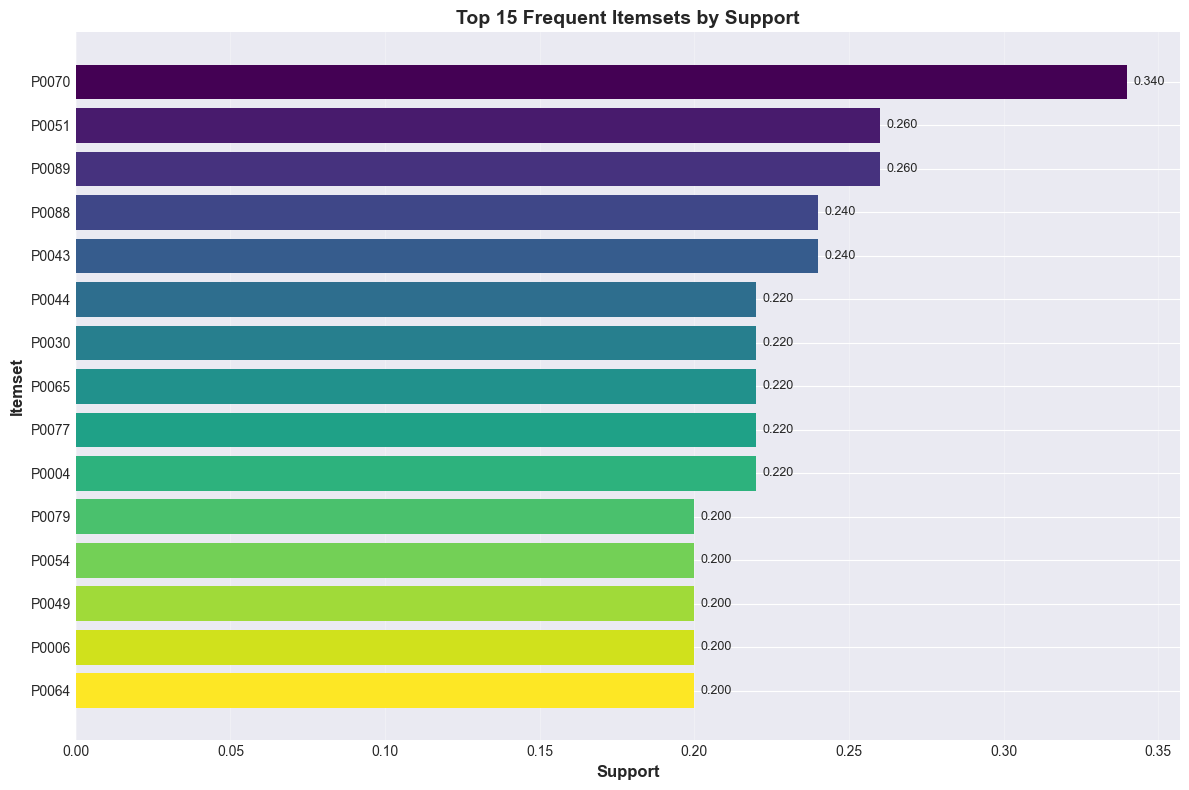


Top itemset: P0070
   Support: 0.340 (34.0%)


In [32]:
# Visualizations of frequent itemsets
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Get top 15 itemsets by support (only size 1-3)
top_itemsets = frequent_itemsets_small.nlargest(15, 'support').copy()

# Labels
top_itemsets['label'] = top_itemsets['itemsets_str'].apply(
    lambda x: x[:40] + '...' if len(x) > 40 else x
)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_itemsets)), top_itemsets['support'].values, 
               color=plt.cm.viridis(np.linspace(0, 1, len(top_itemsets))))

ax.set_yticks(range(len(top_itemsets)))
ax.set_yticklabels(top_itemsets['label'].values, fontsize=10)
ax.set_xlabel('Support', fontsize=12, fontweight='bold')
ax.set_ylabel('Itemset', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Frequent Itemsets by Support', fontsize=14, fontweight='bold')
ax.invert_yaxis() 

# Labels
for i, (bar, support) in enumerate(zip(bars, top_itemsets['support'].values)):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{support:.3f}', va='center', fontsize=9)

# Grid
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nTop itemset: {top_itemsets.iloc[0]['itemsets_str']}")
print(f"   Support: {top_itemsets.iloc[0]['support']:.3f} ({top_itemsets.iloc[0]['support']*100:.1f}%)")

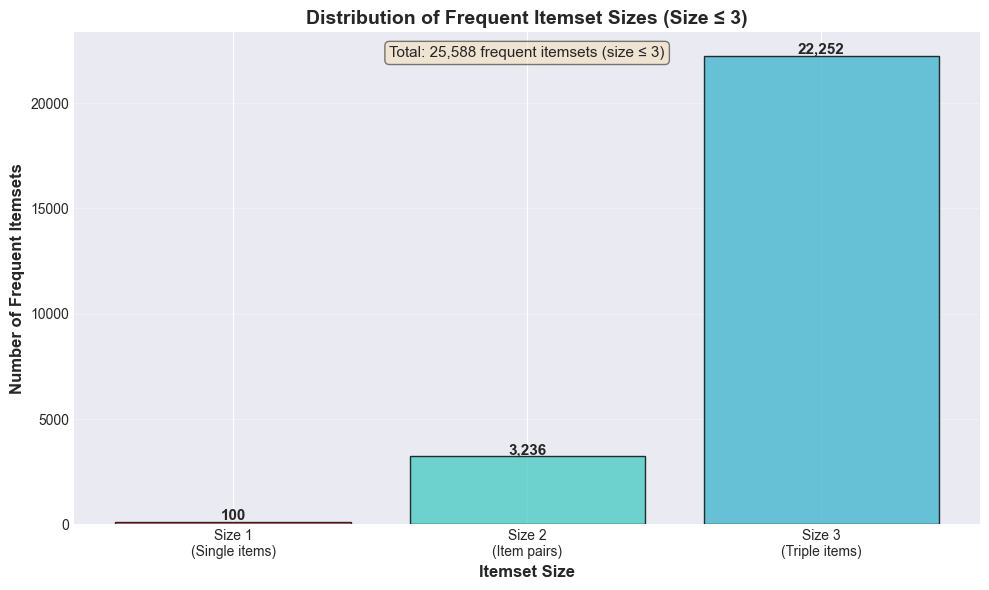


Summary:
  Size 1 itemsets: 100 (most frequent single items)
  Size 2 itemsets: 3,236 (product pairs)
  Size 3 itemsets: 22,252 (product triples)


In [33]:
# Bar chart of itemset size distribution (only sizes 1-3) 
size_counts = frequent_itemsets_small['size'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(size_counts.index, size_counts.values, color=colors, edgecolor='black', alpha=0.8)

ax.set_xlabel('Itemset Size', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Frequent Itemsets', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Frequent Itemset Sizes (Size ≤ 3)', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Size 1\n(Single items)', 'Size 2\n(Item pairs)', 'Size 3\n(Triple items)'])

# Labels
for bar, count in zip(bars, size_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', fontsize=11, fontweight='bold')

total_itemsets = len(frequent_itemsets_small)
ax.text(0.5, 0.95, f'Total: {total_itemsets:,} frequent itemsets (size ≤ 3)',
        transform=ax.transAxes, ha='center', fontsize=11, 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Size 1 itemsets: {size_counts[1]:,} (most frequent single items)")
print(f"  Size 2 itemsets: {size_counts[2]:,} (product pairs)")
print(f"  Size 3 itemsets: {size_counts[3]:,} (product triples)")
